# Cross-modal integration: Cell Painting morphology vs. scRNA-seq

`hepg2_cells.h5ad` holds single-cell RNA-seq of HepG2 cells (389,085 cells x
62,710 genes) treated with 120 small molecules, annotated with a coarse
mechanism-of-action label (`moa-fine`, 21 classes). The morphology profiles
analyzed in `morphology_umap_analysis.ipynb` cover a ~2464-compound
bioactive library screened by Cell Painting in (among others) four HepG2
production sites.

The two datasets don't share an observation-level key: morphology
observations are per-well aggregate profiles, gene expression observations
are individual cells. The only thing they share is **compound identity**, so
"integration" here means building one profile per compound in each modality
and asking whether the two modalities agree on which compounds resemble each
other / share a mechanism of action - not merging rows directly.

Between-plate percent replicating, consensus aggregation, and DMSO activity
(copairs mAP) are in `morphology_expression_qc.ipynb`.

Pipeline:

1. Match the 120 `hepg2_cells.h5ad` drug names to the morphology library by
   name, synonym, and salt/hydrate-suffix stripping.
2. Reduce gene expression to one PCA embedding per drug (cell-level PCA,
   averaged per drug).
3. Reduce morphology to one PCA embedding per compound (well-level PCA over
   the pooled HepG2 sites, averaged per compound), reusing the same
   normalization and well-annotation logic as the morphology notebook.
4. On the compounds present in both: correlate the two modalities'
   compound-compound distance matrices (a Mantel-style test), compare how
   well each modality's PCA space separates `moa-fine` groups (silhouette),
   and visualize a joint embedding.
5. Supervised `moa-fine` prediction (drop the uncertain/`unclear` class)
   with elastic-net logistic regression and an MLP, from morphology,
   expression, and the concatenated joint space.
6. Export paired well-level / cell-level `.h5ad` files for the shared set.

In [40]:
import glob
import os
import re
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pycytominer import feature_select, normalize
from pycytominer.cyto_utils import infer_cp_features
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
N_PCS = 30

PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
    "#008300", "#4a3aa7", "#e34948", "#6b4226", "#38a5b0",
    "#a24fbf", "#c2914e", "#5a6bd6", "#c65da0", "#6f9e1f",
    "#d65f5f", "#3f7d8c", "#9a7dcb", "#b25b2a", "#4f9d6e",
    "#8c8c8c",
]

## 1. Load gene expression

`hepg2_cells.h5ad` is raw UMI counts (sparse, `float32`). `drug` and
`moa-fine` are per-cell categorical annotations; there is no vehicle/DMSO
control group in this file, so expression profiles below are compared to
each other, not to an untreated baseline. The morphology side is different:
the raw per-well annotation files do carry 784 DMSO negative-control wells
per HepG2 site (`Metadata_EOS == "DMSO"`), silently dropped so far because
`load_well_pdid` below only resolves wells to a compound `pdid` and DMSO has
none - section 10 recovers them for a negative-control-based activity check.


In [41]:
# C:\Users\nbrouwer1\Local projects\cell-painting\data\WS4_data\TAHOE single_cell_level
rna = ad.read_h5ad("../../data/WS4_data/TAHOE single_cell_level/hepg2_cells.h5ad")
rna.var_names = rna.var["gene_symbol"].astype(str)
rna.var_names_make_unique()

print(f"{rna.n_obs} cells x {rna.n_vars} genes")
print(f"{rna.obs['drug'].nunique()} drugs, {rna.obs['plate'].nunique()} plates, "
      f"{rna.obs['moa-fine'].nunique()} moa-fine classes, cell line {rna.obs['cell_line_id'].unique().tolist()}")

drug_summary = (
    rna.obs.groupby("drug", observed=True)
    .agg(n_cells=("drug", "size"), moa_fine=("moa-fine", "first"))
    .sort_values("n_cells")
)
drug_summary.head()


389085 cells x 62710 genes
120 drugs, 14 plates, 21 moa-fine classes, cell line ['CVCL_1098']


,n_cells,moa_fine
drug,,
Menadione,925,unclear
Clofarabine,1006,DNA synthesis/repair inhibitor
Pemetrexed,1015,DNA synthesis/repair inhibitor
Canagliflozin,1079,Glucose transporter inhibitor
Silodosin,1110,unclear


## 2. Match compounds between datasets

The morphology library's compound reference
(`annotations/pd_export_..._compounds_standardized.csv`) gives a canonical
`name` plus a `;`-separated `synonyms` list per `pdid`. Match each
`hepg2_cells.h5ad` drug name against that reference in three passes: exact
name, then synonym, then the same two checks after stripping a trailing
salt/hydrate/formulation suffix - either parenthetical (e.g. `"Idarubicin
(hydrochloride)"` -> `"Idarubicin"`) or a bare trailing salt-form word (e.g.
`"Larotrectinib sulfate"` -> `"Larotrectinib"`, `"Ralimetinib dimesylate"` ->
`"Ralimetinib"`) - these free-text name differences are the main source of
missed matches, not real compound identity differences. This resolves all
120 drugs to a `pdid` - a perfect match.


In [43]:
ANNOTATION_DIR = "../../data/WS4_data/OpenScreen morphology-20260901T075256Z-1-001/OpenScreen morphology/annotations/annotations"

compounds = pd.read_csv(os.path.join(ANNOTATION_DIR, "pd_export_04_2022_2464_compounds_standardized.csv"))
compounds = compounds.drop_duplicates(subset="name", keep="first")
name_to_pdid = dict(zip(compounds["name"].str.lower().str.strip(), compounds["pdid"]))

synonym_to_pdid = {}
for _, row in compounds.iterrows():
    for syn in str(row["synonyms"] or "").split(";"):
        syn = syn.strip().lower()
        if syn:
            synonym_to_pdid.setdefault(syn, row["pdid"])

# Common salt/hydrate/counter-ion suffixes that show up as a bare trailing
# word rather than inside parentheses (e.g. "Larotrectinib sulfate",
# "Ralimetinib dimesylate") - stripped repeatedly in case more than one is
# stacked (e.g. "... dihydrochloride hydrate").
SALT_SUFFIX_RE = re.compile(
    r"\s+(?:hydrochlorides?|dihydrochloride|trihydrochloride|sulfates?|disulfate|"
    r"bisulfate|mesylate|dimesylate|tosylate|besylate|maleate|fumarate|"
    r"citrate|acetate|phosphate|diphosphate|hydrobromide|dihydrobromide|"
    r"succinate|oxalate|nitrate|lactate|malate|gluconate|tartrate|bitartrate|"
    r"hemihydrate|monohydrate|dihydrate|trihydrate|tetrahydrate|hydrate|"
    r"sodium|potassium|calcium|iodide|bromide|chloride|palmitate|stearate|"
    r"benzoate|carbonate|bicarbonate|pamoate|isethionate|napadisylate|"
    r"edisylate)\s*$",
    re.IGNORECASE,
)


def strip_formulation_suffix(name: str) -> str:
    name = re.sub(r"\s*\([^)]*\)\s*$", "", name).strip()
    prev = None
    while prev != name:
        prev = name
        name = SALT_SUFFIX_RE.sub("", name).strip()
    return name


def match_drug_to_pdid(drug: str) -> str | None:
    key = drug.lower().strip()
    for candidate in (key, strip_formulation_suffix(key)):
        if candidate in name_to_pdid:
            return name_to_pdid[candidate]
        if candidate in synonym_to_pdid:
            return synonym_to_pdid[candidate]
    return None


drug_to_pdid = {d: match_drug_to_pdid(d) for d in rna.obs["drug"].cat.categories}
n_matched = sum(v is not None for v in drug_to_pdid.values())
print(f"Matched {n_matched}/{len(drug_to_pdid)} drugs to the morphology compound reference")
print("Unmatched:", [d for d, p in drug_to_pdid.items() if p is None])

Matched 120/120 drugs to the morphology compound reference
Unmatched: []


## 3. Gene expression: cell-level PCA, averaged per drug

Standard scanpy pipeline (total-count normalize, log1p, highly-variable
genes, PCA) at single-cell resolution, then average each drug's cells'
PC coordinates into one embedding per drug. Averaging post-PCA (rather than
pseudobulking raw counts pre-PCA) keeps the gene-expression side on the same
"reduce fine-grained observations to one PCA space, then average within
group" logic used for morphology below.


In [27]:
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
sc.pp.pca(rna, n_comps=N_PCS, mask_var="highly_variable", random_state=RANDOM_STATE)

rna_pcs = pd.DataFrame(rna.obsm["X_pca"], index=rna.obs_names)
rna_pcs["drug"] = rna.obs["drug"].to_numpy()
rna_compound_pca = rna_pcs.groupby("drug", observed=True).mean()

moa_by_drug = rna.obs.groupby("drug", observed=True)["moa-fine"].first()

print(f"Per-drug expression embedding: {rna_compound_pca.shape}")
rna_compound_pca.head()


Per-drug expression embedding: (120, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
drug,,,,,,,,,,,,,,,,,,,,,
18β-Glycyrrhetinic acid,0.302304,-0.545984,0.356316,-0.089024,-0.013785,-0.025536,0.243104,0.087827,-0.006344,0.075287,...,-0.129787,-0.041849,0.015050,0.048321,0.031882,-0.023476,0.031685,0.047019,0.102022,0.010792
5-Fluorouracil,-0.366180,0.799737,-0.228654,0.322678,-0.415608,-0.253918,-0.181348,-0.281235,-0.104727,-0.251689,...,0.032546,0.110452,-0.002552,-0.022824,-0.001909,-0.061364,-0.100724,-0.005887,0.066062,0.040238
8-Hydroxyquinoline,1.003545,-0.496191,0.224861,-0.049724,-0.011082,0.076248,0.203890,0.204085,-0.090487,-0.195492,...,0.010113,-0.026299,0.024974,-0.079174,-0.006926,-0.016738,-0.024223,-0.126444,-0.037333,-0.049592
AT7519,0.267017,-0.213019,0.323521,0.073948,0.050305,0.052901,0.051460,0.188226,0.110703,0.054173,...,-0.092122,-0.004392,0.024753,0.087732,-0.050142,0.041367,0.082586,0.120788,0.053169,-0.002172
AZD-8055,0.182385,0.002434,-0.053235,-0.115544,0.012579,0.151400,-0.018940,0.336889,0.063267,0.420353,...,0.149069,-0.159854,-0.029057,-0.049904,-0.130794,0.064152,0.030732,0.099636,0.154699,-0.069731


## 4. Morphology: well-level PCA over pooled HepG2 sites, averaged per compound

Reuses the same loading / per-plate `mad_robustize` normalization / well-
annotation join as `morphology_umap_analysis.ipynb`, restricted to the four
HepG2 production sites (`FMP_U2OS` is excluded - the gene expression data is
HepG2 only). Feature selection is run once on the pooled HepG2 profiles so
all four sites share one feature set, mirroring the "combined" analysis in
the morphology notebook.


In [44]:
# abspath: CWD + relative path exceeds Windows MAX_PATH before `..` collapses
DATA_DIR = os.path.abspath(
    "../../data/WS4_data/OpenScreen morphology-20260901T075256Z-1-001/"
    "OpenScreen morphology/aggregated_data/aggregated_data/"
)
HEPG2_SITES = [d for d in sorted(os.listdir(DATA_DIR)) if d.endswith("HepG2")]
COMPARTMENTS = ["Cells", "Nuc", "Cyto"]

PLATE_RE = re.compile(r"B\d{3,}")
REPLICATE_RE = re.compile(r"(?<![A-Za-z])R\d+")


def parse_plate_replicate(filename: str) -> tuple[str, str]:
    return PLATE_RE.search(filename).group(), REPLICATE_RE.search(filename).group()


def load_site_profiles(site_dir: str, site_name: str) -> pd.DataFrame:
    frames = []
    for f in sorted(glob.glob(os.path.join(site_dir, "*.csv"))):
        d = pd.read_csv(os.path.abspath(f))
        feature_cols = [c for c in d.columns if not c.startswith("Metadata_")]
        d[feature_cols] = d[feature_cols].astype("float32")
        plate, replicate = parse_plate_replicate(os.path.basename(f))
        d["Metadata_Site"] = site_name
        d["Metadata_PlateID"] = plate
        d["Metadata_Replicate"] = replicate
        d["Metadata_SourceFile"] = f"{site_name}_{plate}_{replicate}"
        frames.append(d)
    return pd.concat(frames, ignore_index=True)


def normalize_per_plate(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    parts = [
        normalize(
            group, features=features, meta_features="infer",
            samples="all", method="mad_robustize",
        )
        for _, group in df.groupby("Metadata_SourceFile")
    ]
    return pd.concat(parts, ignore_index=True)


print(f"HepG2 sites: {HEPG2_SITES}")
hepg2_raw = {site: load_site_profiles(os.path.join(DATA_DIR, site), site) for site in HEPG2_SITES}

FEATURES = infer_cp_features(next(iter(hepg2_raw.values())), compartments=COMPARTMENTS)
hepg2_normalized = {site: normalize_per_plate(df, FEATURES) for site, df in hepg2_raw.items()}
hepg2_pooled = pd.concat(hepg2_normalized.values(), ignore_index=True)
print(f"{len(hepg2_pooled)} wells pooled across {len(HEPG2_SITES)} HepG2 sites, {len(FEATURES)} inferred features")


HepG2 sites: ['FMP_HepG2', 'IMTM_HepG2', 'MEDINA_HepG2', 'USC_HepG2']
42847 wells pooled across 4 HepG2 sites, 2977 inferred features


In [29]:
FEATURE_SELECT_OPS = [
    "variance_threshold", "frequency_threshold", "correlation_threshold",
    "drop_na_columns", "blocklist", "drop_outliers",
]
hepg2_selected = feature_select(hepg2_pooled, features=FEATURES, operation=FEATURE_SELECT_OPS)
morph_feature_cols = [c for c in hepg2_selected.columns if not c.startswith("Metadata_")]
print(f"{len(morph_feature_cols)} features selected on pooled HepG2 data")

SITE_ANNOTATION_FILES = {
    "FMP_HepG2": "2022-07-08_Annotation_Bioactives_HepG2.csv",
    "IMTM_HepG2": "2023-08-14_Annotation2_IMTM_HepG2.csv",
    "MEDINA_HepG2": "2023-11-28_Annotation_MEDINA_HepG2.csv",
    "USC_HepG2": "2023-11-28_Annotation_USC_HepG2.csv",
}
eos_to_pdid = pd.read_csv(os.path.join(ANNOTATION_DIR, "2024-08-02_EOS_pdid.csv"))
eos_to_pdid_map = dict(zip(eos_to_pdid["Metadata_EOS"], eos_to_pdid["Metadata_pdid"]))


def load_well_pdid(site: str) -> pd.DataFrame:
    ann = pd.read_csv(os.path.join(ANNOTATION_DIR, SITE_ANNOTATION_FILES[site]))
    ann = ann.rename(columns={"Metadata_Plate": "Metadata_PlateID", "Metadata_Batch": "Metadata_Replicate"})
    ann["Metadata_pdid"] = ann["Metadata_EOS"].map(eos_to_pdid_map)
    ann["Metadata_negcon"] = ann["Metadata_EOS"] == "DMSO"
    return ann[["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate", "Metadata_pdid", "Metadata_negcon"]]


hepg2_selected = pd.concat(
    [
        group.merge(load_well_pdid(site), on=["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate"], how="left")
        for site, group in hepg2_selected.groupby("Metadata_Site")
    ],
    ignore_index=True,
)
print(f"{hepg2_selected['Metadata_pdid'].notna().mean():.1%} of HepG2 wells resolved to a pdid")


636 features selected on pooled HepG2 data
91.6% of HepG2 wells resolved to a pdid


In [30]:
morph_adata = ad.AnnData(
    X=hepg2_selected[morph_feature_cols].to_numpy(dtype=np.float32),
    obs=hepg2_selected[["Metadata_Site", "Metadata_pdid"]].reset_index(drop=True),
)
n_pcs_morph = min(N_PCS, morph_adata.n_vars - 1, morph_adata.n_obs - 1)
sc.pp.pca(morph_adata, n_comps=n_pcs_morph, random_state=RANDOM_STATE)

pdid_to_drug = {pdid: drug for drug, pdid in drug_to_pdid.items() if pdid is not None}

morph_pcs = pd.DataFrame(morph_adata.obsm["X_pca"], index=morph_adata.obs_names)
morph_pcs["drug"] = morph_adata.obs["Metadata_pdid"].map(pdid_to_drug).to_numpy()
morph_compound_pca = morph_pcs.dropna(subset=["drug"]).groupby("drug").mean()

print(f"Per-compound morphology embedding: {morph_compound_pca.shape}")
morph_compound_pca.head()


Per-compound morphology embedding: (119, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
drug,,,,,,,,,,,,,,,,,,,,,
18β-Glycyrrhetinic acid,-6.399391,-1.832656,-0.997449,0.897169,2.423189,-1.025984,1.728316,-0.065956,0.500163,2.347825,...,-0.137488,0.533172,0.535945,-0.361875,0.242810,-0.645517,-0.571938,0.736579,-0.372295,0.220267
5-Fluorouracil,1.409768,21.360699,10.415127,-7.124666,3.451004,-4.621123,0.976498,3.075191,-4.475805,3.289305,...,0.013164,-1.460847,1.574720,0.868977,4.448577,0.459401,0.732453,-1.817027,-1.957580,3.731519
8-Hydroxyquinoline,-8.338182,2.989308,1.421962,-0.004674,-7.868106,-3.681027,2.450292,3.361909,-7.913990,-0.562656,...,1.162534,-0.001621,1.251597,5.869560,-1.649582,1.629254,-0.599179,-1.435223,1.748671,-0.497001
AT7519,-12.874369,18.154440,-18.858919,23.290268,-24.372021,-11.832271,6.593819,16.880598,2.072663,-3.027056,...,-2.972511,1.245775,-0.208994,0.811817,-3.893699,0.784054,-0.356019,-2.010056,3.856692,0.560593
AZD-8055,10.100125,14.107728,6.865195,-1.750074,11.126227,6.824071,-1.361173,10.689241,-1.385394,3.372102,...,1.564076,4.433946,2.726864,-1.334951,1.383556,1.066043,0.221949,-0.280879,-4.267226,-0.880175


## 5. Cross-modal agreement

Restrict to compounds with both a morphology and an expression embedding,
z-score each modality's PCs across those compounds (so no single PC or
modality dominates just by scale), then ask two independent questions:

- **Do the modalities agree on compound-compound relationships?** Correlate
  (Spearman) the upper triangle of the two compound-compound Euclidean
  distance matrices - a Mantel-style test - with a permutation null (shuffle
  one matrix's compound labels) for a p-value.
- **Does either modality recover `moa-fine` groups on its own?** Silhouette
  score using `moa-fine` labels, computed separately in the morphology PCA
  space, the expression PCA space, and the concatenated joint space
  (restricted to MoA classes with >=2 shared compounds, since a
  singleton "cluster" has no well-defined silhouette).


In [31]:
def zscore(df: pd.DataFrame) -> pd.DataFrame:
    std = df.std(ddof=0).replace(0, 1)
    return (df - df.mean()) / std


shared_compounds = sorted(set(morph_compound_pca.index) & set(rna_compound_pca.index))
print(f"{len(shared_compounds)} compounds have both a morphology and an expression embedding")

morph_z = zscore(morph_compound_pca.loc[shared_compounds])
rna_z = zscore(rna_compound_pca.loc[shared_compounds])

dist_morph = squareform(pdist(morph_z.to_numpy()))
dist_rna = squareform(pdist(rna_z.to_numpy()))
iu = np.triu_indices(len(shared_compounds), k=1)

mantel_r, _ = spearmanr(dist_morph[iu], dist_rna[iu])

rng = np.random.RandomState(RANDOM_STATE)
n_perm = 999
idx = np.arange(len(shared_compounds))
null_rs = np.empty(n_perm)
for i in range(n_perm):
    perm = rng.permutation(idx)
    null_rs[i], _ = spearmanr(dist_morph[iu], dist_rna[np.ix_(perm, perm)][iu])
mantel_p = (np.sum(np.abs(null_rs) >= abs(mantel_r)) + 1) / (n_perm + 1)

print(f"Mantel-style correlation between morphology and expression distance matrices: "
      f"r={mantel_r:.3f}, permutation p={mantel_p:.3f} (n_perm={n_perm})")


119 compounds have both a morphology and an expression embedding
Mantel-style correlation between morphology and expression distance matrices: r=0.334, permutation p=0.001 (n_perm=999)


In [32]:
moa_shared = moa_by_drug.reindex(shared_compounds)
moa_group_size = moa_shared.value_counts()
moa_mask = moa_shared.isin(moa_group_size[moa_group_size >= 2].index).to_numpy()
print(f"{moa_mask.sum()}/{len(shared_compounds)} shared compounds have a moa-fine class with >=2 members")

# Equal-variance-contribution joint space: each modality's z-scored PCs
# rescaled by 1/sqrt(n_pcs) so neither dominates Euclidean distance just by
# having more components.
joint_z = np.concatenate(
    [morph_z.to_numpy() / np.sqrt(morph_z.shape[1]), rna_z.to_numpy() / np.sqrt(rna_z.shape[1])],
    axis=1,
)

silhouette_by_moa = pd.Series(
    {
        "morphology": silhouette_score(morph_z.to_numpy()[moa_mask], moa_shared[moa_mask]),
        "expression": silhouette_score(rna_z.to_numpy()[moa_mask], moa_shared[moa_mask]),
        "joint": silhouette_score(joint_z[moa_mask], moa_shared[moa_mask]),
    },
    name="silhouette_by_moa_fine",
)
silhouette_by_moa


118/119 shared compounds have a moa-fine class with >=2 members


morphology   -0.260460
expression   -0.237036
joint        -0.188330
Name: silhouette_by_moa_fine, dtype: float64

## Export compound-level embeddings

Write the z-scored per-compound PCA spaces (morphology, expression) and the
equal-variance-contribution (EVPC) concatenation to
`data/compound_embeddings/`, one `.h5ad` per space. These are the inputs for
`morphology_expression_downstream_tasks.ipynb`.


In [33]:
EMBEDDING_DIR = "./data/compound_embeddings"
os.makedirs(EMBEDDING_DIR, exist_ok=True)

emb_obs = pd.DataFrame(
    {
        "Metadata_Drug": list(shared_compounds),
        "Metadata_moa_fine": moa_shared.astype(str).to_numpy(),
        "Metadata_pdid": [str(drug_to_pdid[d]) for d in shared_compounds],
    },
    index=list(shared_compounds),
)


def _pc_var(prefix: str, n: int) -> pd.DataFrame:
    return pd.DataFrame(index=[f"{prefix}{i}" for i in range(n)])


emb_morph = ad.AnnData(
    X=morph_z.to_numpy().astype(np.float32),
    obs=emb_obs.copy(),
    var=_pc_var("PC", morph_z.shape[1]),
)
emb_morph.uns["space"] = "morphology"
emb_morph.uns["scaling"] = "zscore_per_pc"

emb_expr = ad.AnnData(
    X=rna_z.to_numpy().astype(np.float32),
    obs=emb_obs.copy(),
    var=_pc_var("PC", rna_z.shape[1]),
)
emb_expr.uns["space"] = "expression"
emb_expr.uns["scaling"] = "zscore_per_pc"

n_pcs_morph_z, n_pcs_expr_z = morph_z.shape[1], rna_z.shape[1]
emb_joint = ad.AnnData(
    X=joint_z.astype(np.float32),
    obs=emb_obs.copy(),
    var=pd.DataFrame(
        index=[f"morphology_PC{i}" for i in range(n_pcs_morph_z)]
        + [f"expression_PC{i}" for i in range(n_pcs_expr_z)]
    ),
)
emb_joint.uns["space"] = "joint_evpc"
emb_joint.uns["scaling"] = "zscore_per_pc_then_1_over_sqrt_n_pcs"
emb_joint.uns["evpc_morphology_n_pcs"] = int(n_pcs_morph_z)
emb_joint.uns["evpc_expression_n_pcs"] = int(n_pcs_expr_z)
emb_joint.uns["evpc_morphology_scale"] = float(1.0 / np.sqrt(n_pcs_morph_z))
emb_joint.uns["evpc_expression_scale"] = float(1.0 / np.sqrt(n_pcs_expr_z))

for name, adata in (
    ("morphology", emb_morph),
    ("expression", emb_expr),
    ("joint_evpc", emb_joint),
):
    path = os.path.join(EMBEDDING_DIR, f"{name}.h5ad")
    adata.write_h5ad(path)
    print(f"{path}: {adata.n_obs} compounds x {adata.n_vars} features")


./data/compound_embeddings\morphology.h5ad: 119 compounds x 30 features
./data/compound_embeddings\expression.h5ad: 119 compounds x 30 features
./data/compound_embeddings\joint_evpc.h5ad: 119 compounds x 60 features


## 6. Joint embedding

UMAP of the shared compounds in three spaces - morphology only, expression
only, and the equal-variance-contribution joint space from above - each
colored by `moa-fine` to visually compare how well each space groups
compounds by mechanism.


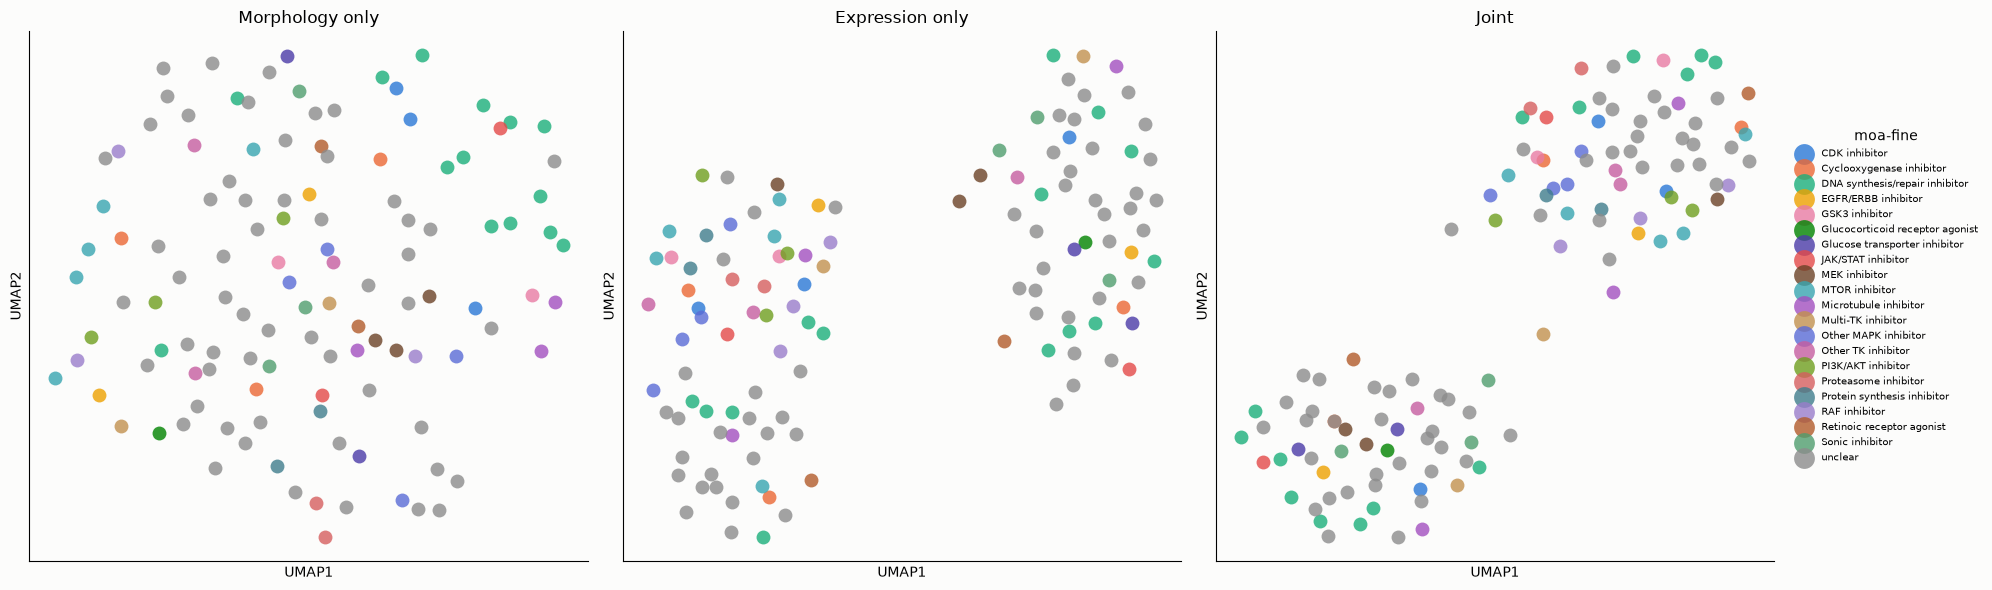

In [34]:
def embed(X: np.ndarray, seed: int = RANDOM_STATE) -> ad.AnnData:
    a = ad.AnnData(X=X.astype(np.float32))
    sc.pp.neighbors(a, use_rep="X", random_state=seed)
    sc.tl.umap(a, random_state=seed)
    return a


def color_map(categories, palette=PALETTE):
    cats = sorted(set(categories))
    return {c: palette[i % len(palette)] for i, c in enumerate(cats)}


def plot_umap(ax, xy, labels, title, cmap):
    for cat, color in cmap.items():
        mask = labels == cat
        ax.scatter(xy[mask, 0], xy[mask, 1], s=100, alpha=0.8, color=color, linewidths=0, label=cat)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)


moa_labels = moa_shared.to_numpy()
cmap = color_map(moa_labels)

embeddings = {
    "Morphology only": embed(morph_z.to_numpy()),
    "Expression only": embed(rna_z.to_numpy()),
    "Joint": embed(joint_z),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (title, a) in zip(axes, embeddings.items()):
    plot_umap(ax, a.obsm["X_umap"], moa_labels, title, cmap)
axes[-1].legend(
    markerscale=1.5, fontsize=7, frameon=False, loc="center left",
    bbox_to_anchor=(1.02, 0.5), title="moa-fine",
)
fig.tight_layout()
plt.show()


### What drives the two blobs in the expression-only UMAP?

The `moa-fine` colors above are mixed freely within each blob, so the split
isn't mechanism-of-action. Checking the actual PC1 gene loadings (PC1 is
the axis separating the two blobs) identifies it directly: it's a
proteotoxic/heat-shock stress-response axis, not a technical batch effect.


In [35]:
pc1_loadings = pd.Series(rna.varm["PCs"][:, 0], index=rna.var_names)

print("Top genes on the 'stressed' pole of PC1 (heat-shock / unfolded-protein / NF-kB response):")
print(pc1_loadings.sort_values().head(10))
print("\nTop genes on the 'unstressed' pole of PC1 (normal hepatocyte lipid/lipoprotein identity):")
print(pc1_loadings.sort_values(ascending=False).head(10))

drug_pc1 = rna_compound_pca[0].sort_values()
print("\nMost 'stressed' drugs (most negative mean PC1):")
print(drug_pc1.head(6))
print("\nMost 'unstressed' drugs (most positive mean PC1):")
print(drug_pc1.tail(6))


Top genes on the 'stressed' pole of PC1 (heat-shock / unfolded-protein / NF-kB response):
gene_symbol
DDIT4      -0.125406
HSPA5      -0.084773
ALB        -0.077449
TNFAIP3    -0.071315
NFKBIA     -0.068094
AHSG       -0.067420
HSPH1      -0.067155
WDR45B     -0.067149
HSP90AA1   -0.066352
MDM2       -0.063992
dtype: float64

Top genes on the 'unstressed' pole of PC1 (normal hepatocyte lipid/lipoprotein identity):
gene_symbol
GPC6         0.253764
FRMD5        0.223563
TIMP1        0.221459
SERPINA3     0.216284
DCBLD2       0.203035
IGFBP1       0.196732
MT2A         0.187862
DNAH17       0.161764
SPRY4-AS1    0.145273
SLC2A3       0.138573
dtype: float64

Most 'stressed' drugs (most negative mean PC1):
drug
Digitoxin                      -1.942203
Homoharringtonine              -1.918935
Bortezomib                     -1.758726
Trametinib (DMSO_TF solvate)   -1.433468
Trametinib                     -1.028469
Ponatinib                      -0.998410
Name: 0, dtype: float32

Most 'unst

## 7. Summary

- **120/120** `hepg2_cells.h5ad` drugs matched to the morphology compound
  reference by name/synonym/salt-suffix stripping - a perfect pdid match
  (fixed from a prior 118/120: `Larotrectinib sulfate` and `Ralimetinib
  dimesylate` were missed because the suffix stripper only handled
  parenthetical salt forms, not a bare trailing salt word). **119** of the
  120 also had enough HepG2 morphology wells to get a compound-level
  embedding; the one gap is `Trametinib` (a pre-existing, unrelated data
  gap - it resolves to a pdid fine, but has zero usable HepG2 wells after
  feature selection/QC - not either of the two compounds this fix added,
  which both do get an embedding).
- **Mantel-style agreement: r = 0.334, permutation p = 0.001** (999
  permutations, 119 shared compounds). Two independently-measured
  modalities - well-level Cell Painting features and single-cell
  transcriptomes - agree on which compounds resemble each other far more
  than chance, even though neither was normalized against the other.
- **`moa-fine` silhouette is negative in all three spaces**
  (morphology -0.26, expression -0.24, joint -0.19, on the 118/119 shared
  compounds whose MoA class has >=2 members): none of the 21 literature MoA
  labels form a tight, well-separated cluster on their own in either
  modality, though the joint space is marginally better than either alone.
  This is consistent with the Mantel result: the modalities agree on overall
  compound-similarity *structure*, but that structure isn't organized cleanly
  along the specific coarse MoA categories used here.
- The expression-only UMAP splits into two blobs that mix `moa-fine` colors
  freely, so it isn't MoA-driven, and it isn't a single dominant plate either
  (most drugs span 3-4 of the 14 plates). The PC1 gene loadings identify it
  directly: the "stressed" pole is loaded on **HSPA5/BiP, HSPH1, HSP90AA1,
  HSPA1A** (heat-shock/unfolded-protein response) plus **NFKBIA, TNFAIP3,
  BIRC3, REL, CYLD** (NF-kB stress signaling), while the "unstressed" pole is
  loaded on normal hepatocyte identity genes (**APOB, GPAM** lipid/
  lipoprotein metabolism). The drugs sitting furthest on the stressed pole -
  Bortezomib (proteasome inhibitor, causing unfolded-protein pileup),
  Homoharringtonine (protein-synthesis inhibitor), Digitoxin (Na/K-ATPase-
  disrupting cardiac glycoside) - are exactly the compounds expected to
  trigger this response, regardless of their annotated `moa-fine` class.
  It's a genuine, compound-driven proteotoxic-stress axis, not a technical
  batch artifact.

- **Supervised MoA prediction (section 7)**: elastic-net logistic regression and MLP, nested stratified CV, `unclear`/`uncertain` dropped. Per-MoA out-of-fold accuracy heatmap across morphology / expression / joint vs. a majority baseline — re-run section 7.
- **QC** (percent replicating, consensus, DMSO mAP): see `morphology_expression_qc.ipynb`.

## 8. Export paired HepG2 h5ad files

Write full-resolution `.h5ad` files, all restricted to the 119 compounds
present in both modalities so they're "paired" by compound identity even
though their row granularity differs (morphology is one row per well,
expression is one row per cell):

- `morphology_<site>.h5ad`, one per HepG2 site (`FMP_HepG2`, `IMTM_HepG2`,
  `MEDINA_HepG2`, `USC_HepG2`) rather than one pooled file, since site is a
  strong batch effect (see `morphology_umap_analysis.ipynb`) and keeping
  sites separate lets downstream users normalize/model that batch effect
  explicitly instead of it being silently baked into a pooled file. `X` =
  the same `mad_robustize`-normalized, feature-selected CP features used in
  section 4, restricted to that site's wells.
- `expression_hepg2.h5ad`: every cell from `hepg2_cells.h5ad` treated with
  one of the 119 shared compounds, `X` = the normalized/log1p expression
  from section 3 (all genes; `var["highly_variable"]` flags the 2000 used
  for PCA). Gene expression has no analogous "production site" to split on.

All files carry a `Metadata_pdid` / `Metadata_Drug` column so they can be
joined by compound identity downstream.


In [38]:
morph_export_df = hepg2_selected.copy()
morph_export_df["Metadata_Drug"] = morph_export_df["Metadata_pdid"].map(pdid_to_drug)
morph_export_df = morph_export_df[morph_export_df["Metadata_Drug"].isin(shared_compounds)].reset_index(drop=True)
morph_export_df["Metadata_moa_fine"] = morph_export_df["Metadata_Drug"].map(moa_by_drug).astype(str)
morph_meta_cols = [c for c in morph_export_df.columns if c.startswith("Metadata_")]

if os.path.exists("./data/morphology_hepg2.h5ad"):
    os.remove("./data/morphology_hepg2.h5ad")  # superseded by the per-site files below

morphology_by_site = {}
for site, site_df in morph_export_df.groupby("Metadata_Site"):
    site_adata = ad.AnnData(
        X=site_df[morph_feature_cols].to_numpy(dtype=np.float32),
        obs=site_df[morph_meta_cols].reset_index(drop=True),
        var=pd.DataFrame(index=morph_feature_cols),
    )
    site_adata.write_h5ad(f"./data/morphology_{site}.h5ad")
    morphology_by_site[site] = site_adata
    print(f"./data/morphology_{site}.h5ad: {site_adata.shape}, {site_adata.obs['Metadata_Drug'].nunique()} compounds")


./data/morphology_FMP_HepG2.h5ad: (471, 636), 118 compounds
./data/morphology_IMTM_HepG2.h5ad: (468, 636), 118 compounds
./data/morphology_MEDINA_HepG2.h5ad: (475, 636), 119 compounds
./data/morphology_USC_HepG2.h5ad: (476, 636), 119 compounds


In [39]:
expression_hepg2 = rna[rna.obs["drug"].isin(shared_compounds)].copy()
expression_hepg2.obs["Metadata_pdid"] = expression_hepg2.obs["drug"].map(drug_to_pdid).astype(str)
expression_hepg2.obs = expression_hepg2.obs.rename(
    columns={"drug": "Metadata_Drug", "moa-fine": "Metadata_moa_fine"}
)
expression_hepg2.write_h5ad("./data/expression_hepg2.h5ad")

print(f"./data/expression_hepg2.h5ad: {expression_hepg2.shape}, "
      f"{expression_hepg2.obs['Metadata_Drug'].nunique()} compounds")

site_drug_sets = {site: set(a.obs["Metadata_Drug"]) for site, a in morphology_by_site.items()}
all_paired = all(s == set(expression_hepg2.obs["Metadata_Drug"]) for s in site_drug_sets.values())
print(f"\nSame compound set in expression file and every per-site morphology file: {all_paired}")
if not all_paired:
    all_drugs = set.union(*site_drug_sets.values())
    for site, drugs in site_drug_sets.items():
        missing = all_drugs - drugs
        if missing:
            print(f"  {site} is missing: {missing} - its well (plate B1004, well N16) is simply "
                  f"absent from that site's raw per-well CSVs (each site's raw well count already "
                  f"falls a bit short of the full 7-plate x 384-well x 4-replicate design in "
                  f"morphology_umap_analysis.ipynb, sect. 1 - a source-data acquisition/QC gap, not "
                  f"something dropped by this notebook's processing)")


./data/expression_hepg2.h5ad: (384533, 62710), 119 compounds

Same compound set in expression file and every per-site morphology file: False
  FMP_HepG2 is missing: {'Idarubicin (hydrochloride)'} - its well (plate B1004, well N16) is simply absent from that site's raw per-well CSVs (each site's raw well count already falls a bit short of the full 7-plate x 384-well x 4-replicate design in morphology_umap_analysis.ipynb, sect. 1 - a source-data acquisition/QC gap, not something dropped by this notebook's processing)
  IMTM_HepG2 is missing: {'Idarubicin (hydrochloride)'} - its well (plate B1004, well N16) is simply absent from that site's raw per-well CSVs (each site's raw well count already falls a bit short of the full 7-plate x 384-well x 4-replicate design in morphology_umap_analysis.ipynb, sect. 1 - a source-data acquisition/QC gap, not something dropped by this notebook's processing)
